# IndiGo Government Sheet — 6-Model Benchmark
Same workflow as Employee notebook:
1. Audit codebook (per-code counts)
2. Clean labels (drop ultra-rare codes)
3. Re-binarise
4. Run 6 models: 3 ML + 2 DL + 1 TL (DeBERTa-v3)


In [1]:
!pip install -q transformers sentencepiece tiktoken protobuf

## 1. Load & audit codebook

In [6]:
import pandas as pd
import numpy as np
import re, html
from collections import Counter

SHEET = 'Government'
df = pd.read_excel('/content/drive/MyDrive/IndiGO Research Projcet/Master_Sheet_final (1).xlsx', sheet_name=SHEET)
print("Columns in DataFrame after loading:", df.columns)

# The 'Final_Label' column was not found. Renaming 'Saurav_Code' to 'Final_Label'.
# If another column should be used (e.g., 'Deepthi_Code' or 'Riha_Code'), please update the line below.
if 'Saurav_Code' in df.columns:
    df.rename(columns={'Saurav_Code': 'Final_Label'}, inplace=True)
    print("Renamed 'Saurav_Code' to 'Final_Label'.")
else:
    print("Warning: 'Final_Label' column not found and 'Saurav_Code' is also missing. Please ensure a label column exists.")

df = df.dropna(subset=['Text', 'Final_Label'])
df = df[df['Final_Label'].str.strip() != ''].reset_index(drop=True)
print(f"Loaded {len(df)} rows from {SHEET}")

# Per-code count (multi-label aware)
codes = []
for label in df['Final_Label'].dropna():
    if label:
        codes.extend([c.strip() for c in label.split(',')])
counts = Counter(codes)

keep   = {c: n for c, n in counts.items() if n >= 10}
review = {c: n for c, n in counts.items() if 3 <= n < 10}
drop   = {c: n for c, n in counts.items() if n < 3}

print(f"\nKEEP ({len(keep)}):  {keep}")
print(f"REVIEW ({len(review)}): {review}")
print(f"DROP ({len(drop)}):   {drop}")

Columns in DataFrame after loading: Index(['ID', 'Text', 'Saurav_Code', 'Deepthi_Code', 'Riha_Code'], dtype='object')
Renamed 'Saurav_Code' to 'Final_Label'.
Loaded 619 rows from Government

KEEP (6):  {'COMMUNICATION_BREAKDOWN': 32, 'PASSENGER_RIGHTS': 14, 'REG_FAIL; POLICY_GAP': 364, 'REG_FAIL': 23, 'ENFORCEMENT_ACTION': 137, 'POLICY_GAP': 28}
REVIEW (1): {'POLICY_GAP; REG_FAIL': 3}
DROP (17):   {'ENFORCEMENT_ACTION; PASSENGER_RIGHTS; REG_FAIL': 2, 'ENFORCEMENT_ACTION; OVERBOOKING; REG_FAIL': 1, 'PASSENGER_RIGHTS; POLICY_GAP': 1, 'POLICY_GAP; STAFF_STRESS': 1, 'ENFORCEMENT_ACTION; REG_FAIL': 1, 'REG_FAIL; PASSENGER_RIGHTS': 1, 'REG_FAIL; TRUST_EROSION': 1, 'TRUST_EROSION; REG_FAIL; COMMUNICATION_BREAKDOWN': 1, 'REG_FAIL; ENFORCEMENT_ACTION; TRUST_EROSION': 1, 'PRICE_SURGE': 1, 'REG_FAIL; ENFORCEMENT_ACTION': 1, 'ENFORCEMENT_ACTION; PASSENGER_RIGHTS': 1, 'PASSENGER_RIGHTS; ENFORCEMENT_ACTION': 1, 'POLICY_GAP; ENFORCEMENT_ACTION; PASSENGER_RIGHTS; REG_FAIL': 1, 'REG_FAIL; POLICY_GAP; E

In [7]:
# Run voting across 3 coders for Government sheet
import pandas as pd
import re
from collections import Counter

CODER_COLS = ['Saurav_Code', 'Deepthi_Code', 'Riha_Code']

def normalize_codes(value):
    if pd.isna(value): return set()
    s = str(value).replace('\n', ',').replace(';', ',')
    return {re.sub(r'\s+','',p).upper() for p in s.split(',') if p.strip()}

def majority_vote(sets_list, min_votes=2):
    non_empty = [s for s in sets_list if len(s) > 0]
    if not non_empty: return set(), 'uncoded'
    counts = Counter()
    for s in non_empty:
        for code in s:
            counts[code] += 1
    final = {c for c, k in counts.items() if k >= min_votes}
    if not final: return set(), 'no_agreement'
    return final, 'majority'

df_gov = pd.read_excel('/content/drive/MyDrive/IndiGO Research Projcet/Master_Sheet_final (1).xlsx', sheet_name='Government')

for col in CODER_COLS:
    df_gov[col + '_norm'] = df_gov[col].apply(normalize_codes)

finals, agreements = [], []
for _, row in df_gov.iterrows():
    sets_list = [row[c + '_norm'] for c in CODER_COLS]
    final, agr = majority_vote(sets_list)
    finals.append(', '.join(sorted(final)) if final else '')
    agreements.append(agr)

df_gov['Final_Label'] = finals
df_gov['Agreement_Level'] = agreements

# Save it back so the rest of the notebook can use it
df = df_gov[['ID', 'Text', 'Final_Label', 'Agreement_Level']]
print(df['Agreement_Level'].value_counts())
print(df.head())

# Save the DataFrame to an Excel file for later use
df.to_excel('/content/drive/MyDrive/IndiGO Research Projcet/Final_voted_labels.xlsx', index=False)

Agreement_Level
majority    619
Name: count, dtype: int64
     ID                                               Text  \
0   124               .Hope IndiGo will not become AdaniGo   
1   118  .It can be a conspiracy. If Adani enter into a...   
2   113  .Why do we have to take refundable ticket palk...   
3   725  .illio s of complaints  of air india setvices ...   
4  3155  1 or 2 Good DGCA chairmen = 1. Roy Paul, 2. E....   

               Final_Label Agreement_Level  
0  COMMUNICATION_BREAKDOWN        majority  
1  COMMUNICATION_BREAKDOWN        majority  
2         PASSENGER_RIGHTS        majority  
3     POLICY_GAP, REG_FAIL        majority  
4     POLICY_GAP, REG_FAIL        majority  


In [8]:
df['Final_Label'].value_counts()

,count
Final_Label,
"POLICY_GAP, REG_FAIL",367
ENFORCEMENT_ACTION,137
COMMUNICATION_BREAKDOWN,32
POLICY_GAP,28
REG_FAIL,23
PASSENGER_RIGHTS,14
"ENFORCEMENT_ACTION, PASSENGER_RIGHTS, POLICY_GAP, REG_FAIL",3
"ENFORCEMENT_ACTION, REG_FAIL",2
"ENFORCEMENT_ACTION, PASSENGER_RIGHTS, REG_FAIL",2


In [9]:
import pandas as pd
import re
from collections import Counter

SHEET = 'Government'
df = pd.read_excel('/content/drive/MyDrive/IndiGO Research Projcet/Master_Sheet_final (1).xlsx', sheet_name=SHEET)

# Check what columns exist
print(f"Columns: {list(df.columns)}\n")

# Use Final_Label if voted; else fall back to running voting on the fly
if 'Final_Label' not in df.columns:
    print("⚠ No Final_Label column — running voting across 3 coders now\n")
    CODER_COLS = ['Saurav_Code', 'Deepthi_Code', 'Riha_Code']

    def normalize_codes(value):
        if pd.isna(value): return set()
        s = str(value).replace('\n', ',').replace(';', ',')
        return {re.sub(r'\s+','',p).upper() for p in s.split(',') if p.strip()}

    for col in CODER_COLS:
        df[col + '_norm'] = df[col].apply(normalize_codes)

    finals, agreements = [], []
    for _, row in df.iterrows():
        sets_list = [row[c + '_norm'] for c in CODER_COLS if row[c + '_norm']]
        if not sets_list:
            finals.append(''); agreements.append('uncoded'); continue
        counts = Counter()
        for s in sets_list:
            for code in s:
                counts[code] += 1
        final = {c for c, k in counts.items() if k >= 2}
        if final:
            finals.append(', '.join(sorted(final)))
            agreements.append('majority')
        else:
            finals.append(''); agreements.append('no_agreement')

    df['Final_Label'] = finals
    df['Agreement_Level'] = agreements

df = df.dropna(subset=['Text', 'Final_Label'])
df = df[df['Final_Label'].astype(str).str.strip() != ''].reset_index(drop=True)
print(f"Loaded {len(df)} rows from {SHEET}\n")

# PROPER multi-separator split
def split_codes(value):
    if pd.isna(value): return []
    s = str(value).replace('\n', ',').replace(';', ',')
    parts = [re.sub(r'\s+', '', p).upper() for p in s.split(',')]
    return [p for p in parts if p]

codes = []
for label in df['Final_Label'].dropna():
    codes.extend(split_codes(label))
counts = Counter(codes)

keep   = {c: n for c, n in counts.items() if n >= 10}
review = {c: n for c, n in counts.items() if 3 <= n < 10}
drop_  = {c: n for c, n in counts.items() if n < 3}

print(f"KEEP ({len(keep)}):    {keep}")
print(f"REVIEW ({len(review)}): {review}")
print(f"DROP ({len(drop_)}):    {drop_}")
print(f"\nTotal code instances: {sum(counts.values())}")
print(f"Multi-label rows: {sum(1 for l in df['Final_Label'] if ',' in l or ';' in l)}/{len(df)}")

Columns: ['ID', 'Text', 'Saurav_Code', 'Deepthi_Code', 'Riha_Code']

⚠ No Final_Label column — running voting across 3 coders now

Loaded 619 rows from Government

KEEP (5):    {'COMMUNICATION_BREAKDOWN': 33, 'PASSENGER_RIGHTS': 23, 'POLICY_GAP': 400, 'REG_FAIL': 402, 'ENFORCEMENT_ACTION': 148}
REVIEW (1): {'TRUST_EROSION': 4}
DROP (4):    {'OVERBOOKING': 1, 'STAFF_STRESS': 1, 'PRICE_SURGE': 1, 'FINANCIAL_LOSS': 1}

Total code instances: 1014
Multi-label rows: 384/619


## 2. Clean codebook
Drop codes with <3 samples (model can't learn from 1-2 examples).
Edit `merge_map` and `drop_codes` based on the audit output above if you want to merge similar codes.

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
# EDIT THESE based on the audit output above
merge_map = {
    # Example: 'OVER_OPTIMISATION': 'MISMANAGEMENT',
    # Add your own merges here
}

# Auto-drop codes with <3 samples
drop_codes = set(drop.keys())     # codes with <3 samples
print(f"Auto-dropping: {drop_codes}")

def clean_labels(label_str):
    if pd.isna(label_str) or not label_str:
        return ''
    codes = [c.strip() for c in label_str.split(',')]
    cleaned = set()
    for c in codes:
        if c in drop_codes:
            continue
        cleaned.add(merge_map.get(c, c))
    return ', '.join(sorted(cleaned))

df['Final_Label_Clean'] = df['Final_Label'].apply(clean_labels)

# Remove rows that became empty after cleanup
df = df[df['Final_Label_Clean'].str.strip() != ''].reset_index(drop=True)

# Verify
codes = []
for l in df['Final_Label_Clean'].dropna():
    if l:
        codes.extend([c.strip() for c in l.split(',')])
print(f"\nAfter cleanup — {len(df)} rows, codes:")
print(Counter(codes))


Auto-dropping: {'PASSENGER_RIGHTS; ENFORCEMENT_ACTION', 'ENFORCEMENT_ACTION; PASSENGER_RIGHTS; REG_FAIL', 'PRICE_SURGE', 'POLICY_GAP; STAFF_STRESS', 'POLICY_GAP; ENFORCEMENT_ACTION; PASSENGER_RIGHTS; REG_FAIL', 'FINANCIAL_LOSS\nTRUST_EROSION', 'PASSENGER_RIGHTS; POLICY_GAP', 'ENFORCEMENT_ACTION; REG_FAIL', 'REG_FAIL; PASSENGER_RIGHTS', 'ENFORCEMENT_ACTION; PASSENGER_RIGHTS', 'ENFORCEMENT_ACTION; PASSENGER_RIGHTS; POLICY_GAP; REG_FAIL', 'ENFORCEMENT_ACTION; OVERBOOKING; REG_FAIL', 'REG_FAIL; TRUST_EROSION', 'REG_FAIL; ENFORCEMENT_ACTION; TRUST_EROSION', 'REG_FAIL; ENFORCEMENT_ACTION', 'REG_FAIL; POLICY_GAP; ENFORCEMENT_ACTION; PASSENGER_RIGHTS', 'TRUST_EROSION; REG_FAIL; COMMUNICATION_BREAKDOWN'}

After cleanup — 618 rows, codes:
Counter({'REG_FAIL': 402, 'POLICY_GAP': 400, 'ENFORCEMENT_ACTION': 148, 'COMMUNICATION_BREAKDOWN': 33, 'PASSENGER_RIGHTS': 23, 'TRUST_EROSION': 4, 'OVERBOOKING': 1, 'STAFF_STRESS': 1, 'FINANCIAL_LOSS': 1})


In [12]:
# Auto-drop is already removing the trash combos correctly
# Now ALSO drop the ultra-rare individual codes after splitting

drop_codes = {
    'OVERBOOKING',    # 1 sample
    'STAFF_STRESS',   # 1 sample (belongs to Employee sheet)
    'FINANCIAL_LOSS', # 1 sample (belongs to Passenger sheet)
    'TRUST_EROSION',  # 4 samples — borderline, but cleaner to drop
}

merge_map = {
    # Nothing to merge — codes are conceptually distinct
}

In [13]:
# Final cleanup decisions for Government sheet
merge_map = {
    # No merges needed — codes are conceptually distinct
}

# Drop ultra-rare codes (after the auto-drop of bad combinations)
drop_codes_extra = {
    'OVERBOOKING',
    'STAFF_STRESS',
    'FINANCIAL_LOSS',
    'TRUST_EROSION',   # only 4 samples — too rare to model reliably
}

# Combine with auto-drop set from audit
drop_codes = set(drop.keys()) | drop_codes_extra
print(f"Total dropping: {len(drop_codes)} codes")

def clean_labels(label_str):
    if pd.isna(label_str) or not label_str:
        return ''
    # Split on ALL separators
    s = str(label_str).replace('\n', ',').replace(';', ',')
    codes = [re.sub(r'\s+', '', c).upper() for c in s.split(',') if c.strip()]
    cleaned = set()
    for c in codes:
        if c in drop_codes:
            continue
        cleaned.add(merge_map.get(c, c))
    return ', '.join(sorted(cleaned))

df['Final_Label_Clean'] = df['Final_Label'].apply(clean_labels)
df = df[df['Final_Label_Clean'].str.strip() != ''].reset_index(drop=True)

# Verify
codes = []
for l in df['Final_Label_Clean'].dropna():
    if l:
        codes.extend([c.strip() for c in l.split(',')])
print(f"\nAfter cleanup — {len(df)} rows")
print(Counter(codes))

Total dropping: 21 codes

After cleanup — 617 rows
Counter({'REG_FAIL': 402, 'POLICY_GAP': 400, 'ENFORCEMENT_ACTION': 148, 'COMMUNICATION_BREAKDOWN': 33, 'PASSENGER_RIGHTS': 23})


## 3. Preprocess & binarise

In [14]:
from sklearn.preprocessing import MultiLabelBinarizer

def clean_text(t):
    t = html.unescape(str(t))
    t = re.sub(r'<br\s*/?>', ' ', t)
    t = re.sub(r'<[^>]+>', '', t)
    t = re.sub(r'http\S+|www\.\S+', ' ', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t

df['clean_text'] = df['Text'].apply(clean_text)
df['label_list'] = df['Final_Label_Clean'].apply(
    lambda x: [c.strip() for c in x.split(',') if c.strip()]
)

mlb = MultiLabelBinarizer()
y = mlb.fit_transform(df['label_list'])
X = df['clean_text'].values
CODES = list(mlb.classes_)

print(f"N = {len(df)}")
print(f"Classes ({len(CODES)}): {CODES}")
print(f"Per-code counts: {dict(zip(CODES, y.sum(axis=0)))}")


N = 617
Classes (5): ['COMMUNICATION_BREAKDOWN', 'ENFORCEMENT_ACTION', 'PASSENGER_RIGHTS', 'POLICY_GAP', 'REG_FAIL']
Per-code counts: {'COMMUNICATION_BREAKDOWN': np.int64(33), 'ENFORCEMENT_ACTION': np.int64(148), 'PASSENGER_RIGHTS': np.int64(23), 'POLICY_GAP': np.int64(400), 'REG_FAIL': np.int64(402)}


In [15]:
len(df)

617

In [16]:
results = {}

In [27]:
import pandas as pd
import numpy as np
import re, html
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import (
    classification_report, f1_score, hamming_loss, multilabel_confusion_matrix
)
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import VotingClassifier, RandomForestClassifier

def evaluate_ml(model_name, build_classifier_fn):
    print(f"\n{'='*80}")
    print(f"Evaluating: {model_name}")
    print(f"{'='*80}")

    N_FOLDS = 5
    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

    fold_scores = []
    all_preds, all_trues = [], []

    for fold, (train_idx, test_idx) in enumerate(kf.split(X), 1):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        print(f"\n{'='*60}")
        print(f"FOLD {fold}")
        print(f"{'='*60}")
        print(f"X_train shape: {X_train.shape}  |  X_test shape: {X_test.shape}")
        print(f"y_train shape: {y_train.shape}  |  y_test shape: {y_test.shape}")
        print(f"\nX_train (first 3):\n{X_train[:3]}")
        print(f"\nX_test  (first 3):\n{X_test[:3]}")
        print(f"\ny_train (first 3):\n{y_train[:3]}")
        print(f"\ny_test  (first 3):\n{y_test[:3]}")

        # TF-IDF on training fold only (no leakage)
        vec = TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True,
        )
        Xtr = vec.fit_transform(X_train)
        Xte = vec.transform(X_test)

        # Build and train classifier
        clf = build_classifier_fn()
        clf.fit(Xtr, y_train)
        y_pred = clf.predict(Xte)

        macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        micro_f1 = f1_score(y_test, y_pred, average='micro', zero_division=0)
        weighted_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        hloss   = hamming_loss(y_test, y_pred)

        fold_scores.append({
            'fold': fold,
            'macro_f1': macro_f1,
            'micro_f1': micro_f1,
            'weighted_f1': weighted_f1,
            'hamming_loss': hloss,
        })

        all_preds.append(y_pred)
        all_trues.append(y_test)

    # ------------------------------------------------------------
    # 5. REPORT CV RESULTS
    # ------------------------------------------------------------
    print("\n" + "="*60)
    print("CROSS-VALIDATION RESULTS (5-fold)")
    print("="*60)
    res = pd.DataFrame(fold_scores)
    print(res.to_string(index=False))
    print(f"\nMean macro-F1:    {res['macro_f1'].mean():.3f} (± {res['macro_f1'].std():.3f})")
    print(f"Mean micro-F1:    {res['micro_f1'].mean():.3f} (± {res['micro_f1'].std():.3f})")
    print(f"Mean weighted-F1: {res['weighted_f1'].mean():.3f} (± {res['weighted_f1'].std():.3f})")
    print(f"Mean Hamming loss:{res['hamming_loss'].mean():.3f}")

    # Pooled per-class report (across all folds)
    y_pred_all = np.vstack(all_preds)
    y_true_all = np.vstack(all_trues)

    print("\n" + "="*60)
    print("PER-CLASS PERFORMANCE (pooled across folds)")
    print("="*60)
    print(classification_report(
        y_true_all, y_pred_all,
        target_names=CODES,
        zero_division=0,
        digits=3,
    ))

    # ------------------------------------------------------------
    # 6. PER-CODE CONFUSION MATRICES
    # ------------------------------------------------------------
    print("\n" + "="*60)
    print("PER-CODE CONFUSION MATRICES")
    print("="*60)
    cms = multilabel_confusion_matrix(y_true_all, y_pred_all)
    for i, code in enumerate(CODES):
        tn, fp, fn, tp = cms[i].ravel()
        print(f"\n{code}:")
        print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")
        if tp + fp > 0:
            print(f"  Precision: {tp/(tp+fp):.3f}")
        if tp + fn > 0:
            print(f"  Recall:    {tp/(tp+fn):.3f}")

    # ------------------------------------------------------------
    # 7. TRAIN FINAL MODEL ON ALL DATA (for inspection / deployment)
    # ------------------------------------------------------------
    final_vec = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True)
    X_full = final_vec.fit_transform(X)

    final_clf = build_classifier_fn()
    final_clf.fit(X_full, y)

    # ------------------------------------------------------------
    # 8. TOP DISTINCTIVE FEATURES PER CODE
    # ------------------------------------------------------------
    print("\n" + "="*60)
    print("TOP 10 DISTINCTIVE WORDS PER CODE")
    print("="*60)
    feature_names = np.array(final_vec.get_feature_names_out())
    for i, code in enumerate(CODES):
        # Check if the estimator has coef_ attribute (e.g., LogisticRegression, LinearSVC)
        # RandomForestClassifier and VotingClassifier do not directly have coef_
        if hasattr(final_clf.estimators_[i], 'coef_'):
            coefs = final_clf.estimators_[i].coef_[0]
            top_idx = np.argsort(coefs)[-10:][::-1]
            top_words = feature_names[top_idx]
            print(f"\n{code}: {', '.join(top_words)}")
        else:
            # Handle cases where feature importance is not directly available via coef_
            print(f"\n{code}: Feature importance not available for this estimator type.")

    results[model_name] = {
        'macro_f1': res['macro_f1'].mean(),
        'macro_std': res['macro_f1'].std(),
        'micro_f1': res['micro_f1'].mean(),
        'weighted_f1': res['weighted_f1'].mean(),
    }

In [28]:
def evaluate_ml(model_name, build_classifier_fn):
    print(f"\n{'='*80}")
    print(f"Evaluating: {model_name}")
    print(f"{'='*80}")

    N_FOLDS = 5
    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

    fold_scores = []
    all_preds, all_trues = [], []

    for fold, (train_idx, test_idx) in enumerate(kf.split(X), 1):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        print(f"\n{'='*60}")
        print(f"FOLD {fold}")
        print(f"{'='*60}")
        print(f"X_train shape: {X_train.shape}  |  X_test shape: {X_test.shape}")
        print(f"y_train shape: {y_train.shape}  |  y_test shape: {y_test.shape}")
        print(f"\nX_train (first 3):\n{X_train[:3]}")
        print(f"\nX_test  (first 3):\n{X_test[:3]}")
        print(f"\ny_train (first 3):\n{y_train[:3]}")
        print(f"\ny_test  (first 3):\n{y_test[:3]}")

        # TF-IDF on training fold only (no leakage)
        vec = TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True,
        )
        Xtr = vec.fit_transform(X_train)
        Xte = vec.transform(X_test)

        # Build and train classifier
        clf = build_classifier_fn()
        clf.fit(Xtr, y_train)
        y_pred = clf.predict(Xte)

        macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        micro_f1 = f1_score(y_test, y_pred, average='micro', zero_division=0)
        weighted_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        hloss   = hamming_loss(y_test, y_pred)

        fold_scores.append({
            'fold': fold,
            'macro_f1': macro_f1,
            'micro_f1': micro_f1,
            'weighted_f1': weighted_f1,
            'hamming_loss': hloss,
        })

        all_preds.append(y_pred)
        all_trues.append(y_test)

    # ------------------------------------------------------------
    # 5. REPORT CV RESULTS
    # ------------------------------------------------------------
    print("\n" + "="*60)
    print("CROSS-VALIDATION RESULTS (5-fold)")
    print("="*60)
    res = pd.DataFrame(fold_scores)
    print(res.to_string(index=False))
    print(f"\nMean macro-F1:    {res['macro_f1'].mean():.3f} (± {res['macro_f1'].std():.3f})")
    print(f"Mean micro-F1:    {res['micro_f1'].mean():.3f} (± {res['micro_f1'].std():.3f})")
    print(f"Mean weighted-F1: {res['weighted_f1'].mean():.3f} (± {res['weighted_f1'].std():.3f})")
    print(f"Mean Hamming loss:{res['hamming_loss'].mean():.3f}")

    # Pooled per-class report (across all folds)
    y_pred_all = np.vstack(all_preds)
    y_true_all = np.vstack(all_trues)

    print("\n" + "="*60)
    print("PER-CLASS PERFORMANCE (pooled across folds)")
    print("="*60)
    print(classification_report(
        y_true_all, y_pred_all,
        target_names=CODES,
        zero_division=0,
        digits=3,
    ))

    # ------------------------------------------------------------
    # 6. PER-CODE CONFUSION MATRICES
    # ------------------------------------------------------------
    print("\n" + "="*60)
    print("PER-CODE CONFUSION MATRICES")
    print("="*60)
    cms = multilabel_confusion_matrix(y_true_all, y_pred_all)
    for i, code in enumerate(CODES):
        tn, fp, fn, tp = cms[i].ravel()
        print(f"\n{code}:")
        print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")
        if tp + fp > 0:
            print(f"  Precision: {tp/(tp+fp):.3f}")
        if tp + fn > 0:
            print(f"  Recall:    {tp/(tp+fn):.3f}")

    # ------------------------------------------------------------
    # 7. TRAIN FINAL MODEL ON ALL DATA (for inspection / deployment)
    # ------------------------------------------------------------
    final_vec = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True)
    X_full = final_vec.fit_transform(X)

    final_clf = build_classifier_fn()
    final_clf.fit(X_full, y)

    # ------------------------------------------------------------
    # 8. TOP DISTINCTIVE FEATURES PER CODE
    # ------------------------------------------------------------
    print("\n" + "="*60)
    print("TOP 10 DISTINCTIVE WORDS PER CODE")
    print("="*60)
    feature_names = np.array(final_vec.get_feature_names_out())
    for i, code in enumerate(CODES):
        if hasattr(final_clf.estimators_[i], 'coef_'):
            coefs = final_clf.estimators_[i].coef_[0]
            top_idx = np.argsort(coefs)[-10:][::-1]
            top_words = feature_names[top_idx]
            print(f"\n{code}: {', '.join(top_words)}")
        else:
            print(f"\n{code}: Feature importance not available for this estimator type.")

    results[model_name] = {
        'macro_f1': res['macro_f1'].mean(),
        'macro_std': res['macro_f1'].std(),
        'micro_f1': res['micro_f1'].mean(),
        'weighted_f1': res['weighted_f1'].mean(),
    }

## 4. ML models (3: LogReg, SVM, Voting)

In [29]:
# ============================================================
# EMPLOYEE SHEET — Baseline Multi-Label Classifier
# TF-IDF + Logistic Regression (One-vs-Rest)
# ============================================================

# The data (df, X, y) and label encoder (mlb) are already prepared by previous cells.
# The 'CODES' variable is also available from CLVh1OLoSEZD.

# Imports are already global or handled within evaluate_ml function
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import (
    classification_report, f1_score, hamming_loss, multilabel_confusion_matrix
)

# Call the new evaluate_ml function
evaluate_ml(
    "ML1: TF-IDF + Logistic Regression",
    lambda: OneVsRestClassifier(
        LogisticRegression(
            class_weight='balanced',
            max_iter=2000,
            C=1.0,
            solver='liblinear',
        )
    )
)


Evaluating: ML1: TF-IDF + Logistic Regression

FOLD 1
X_train shape: (493,)  |  X_test shape: (124,)
y_train shape: (493, 5)  |  y_test shape: (124, 5)

X_train (first 3):
['.Hope IndiGo will not become AdaniGo'
 '.It can be a conspiracy. If Adani enter into aviation business . He control sea ports . Most of the airport controlled by him . Now he will take complete aviation. Itâ€™s not a coincidence itâ€™s a conspiracy. Indigo is the only profit making airline. All other airline are making losses. Govt could have imposed heavy fine. But instead they stopped indigo from flying . ðŸ‘_x008d_'
 '.illio s of complaints of air india setvices at Delhi airports and some other airports Wake up bjp You ruining Modiji name and reputation']

X_test  (first 3):
['.Why do we have to take refundable ticket palkii? If there is a clause that the airlines give us back,double of what we paid if the flight is cancelled then I am ready to buy refundable ticket'
 '100%गलती मोदी सरकार और DGCA की है। जब उन्ह

In [30]:
evaluate_ml(
    "ML1: TF-IDF + Logistic Regression",
    lambda: OneVsRestClassifier(
        LogisticRegression(
            class_weight='balanced',
            max_iter=2000,
            C=1.0,
            solver='liblinear',
        )
    )
)


Evaluating: ML1: TF-IDF + Logistic Regression

FOLD 1
X_train shape: (493,)  |  X_test shape: (124,)
y_train shape: (493, 5)  |  y_test shape: (124, 5)

X_train (first 3):
['.Hope IndiGo will not become AdaniGo'
 '.It can be a conspiracy. If Adani enter into aviation business . He control sea ports . Most of the airport controlled by him . Now he will take complete aviation. Itâ€™s not a coincidence itâ€™s a conspiracy. Indigo is the only profit making airline. All other airline are making losses. Govt could have imposed heavy fine. But instead they stopped indigo from flying . ðŸ‘_x008d_'
 '.illio s of complaints of air india setvices at Delhi airports and some other airports Wake up bjp You ruining Modiji name and reputation']

X_test  (first 3):
['.Why do we have to take refundable ticket palkii? If there is a clause that the airlines give us back,double of what we paid if the flight is cancelled then I am ready to buy refundable ticket'
 '100%गलती मोदी सरकार और DGCA की है। जब उन्ह

In [31]:
print(f"Total rows:          {len(X)}")
print(f"Total label counts:  {y.sum()}")
print(f"Avg labels per row:  {y.sum(axis=1).mean():.2f}")
print()
print("Label distribution:")
for i, code in enumerate(CODES):
    print(f"  {code}: {y[:, i].sum()} samples ({y[:, i].mean()*100:.1f}%)")

Total rows:          617
Total label counts:  1006
Avg labels per row:  1.63

Label distribution:
  COMMUNICATION_BREAKDOWN: 33 samples (5.3%)
  ENFORCEMENT_ACTION: 148 samples (24.0%)
  PASSENGER_RIGHTS: 23 samples (3.7%)
  POLICY_GAP: 400 samples (64.8%)
  REG_FAIL: 402 samples (65.2%)


In [32]:
# ML1 — Logistic Regression
evaluate_ml(
    "ML1: TF-IDF + Logistic Regression",
    lambda: OneVsRestClassifier(LogisticRegression(
        class_weight='balanced', max_iter=2000, C=1.0, solver='liblinear'))
)


Evaluating: ML1: TF-IDF + Logistic Regression

FOLD 1
X_train shape: (493,)  |  X_test shape: (124,)
y_train shape: (493, 5)  |  y_test shape: (124, 5)

X_train (first 3):
['.Hope IndiGo will not become AdaniGo'
 '.It can be a conspiracy. If Adani enter into aviation business . He control sea ports . Most of the airport controlled by him . Now he will take complete aviation. Itâ€™s not a coincidence itâ€™s a conspiracy. Indigo is the only profit making airline. All other airline are making losses. Govt could have imposed heavy fine. But instead they stopped indigo from flying . ðŸ‘_x008d_'
 '.illio s of complaints of air india setvices at Delhi airports and some other airports Wake up bjp You ruining Modiji name and reputation']

X_test  (first 3):
['.Why do we have to take refundable ticket palkii? If there is a clause that the airlines give us back,double of what we paid if the flight is cancelled then I am ready to buy refundable ticket'
 '100%गलती मोदी सरकार और DGCA की है। जब उन्ह

In [33]:
# ML2 — Linear SVM
evaluate_ml(
    "ML2: TF-IDF + Linear SVM",
    lambda: OneVsRestClassifier(LinearSVC(
        class_weight='balanced', C=1.0, max_iter=3000))
)


Evaluating: ML2: TF-IDF + Linear SVM

FOLD 1
X_train shape: (493,)  |  X_test shape: (124,)
y_train shape: (493, 5)  |  y_test shape: (124, 5)

X_train (first 3):
['.Hope IndiGo will not become AdaniGo'
 '.It can be a conspiracy. If Adani enter into aviation business . He control sea ports . Most of the airport controlled by him . Now he will take complete aviation. Itâ€™s not a coincidence itâ€™s a conspiracy. Indigo is the only profit making airline. All other airline are making losses. Govt could have imposed heavy fine. But instead they stopped indigo from flying . ðŸ‘_x008d_'
 '.illio s of complaints of air india setvices at Delhi airports and some other airports Wake up bjp You ruining Modiji name and reputation']

X_test  (first 3):
['.Why do we have to take refundable ticket palkii? If there is a clause that the airlines give us back,double of what we paid if the flight is cancelled then I am ready to buy refundable ticket'
 '100%गलती मोदी सरकार और DGCA की है। जब उन्हें मालूम 

In [34]:
# ML3 — Voting Ensemble (LR + SVM + RF)
def build_voting():
    svm_cal = CalibratedClassifierCV(
        LinearSVC(class_weight='balanced', max_iter=3000), cv=3)
    voting = VotingClassifier(
        estimators=[
            ('lr', LogisticRegression(class_weight='balanced', max_iter=2000, solver='liblinear')),
            ('svm', svm_cal),
            ('rf', RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                          random_state=42, n_jobs=-1)),
        ], voting='soft')
    return OneVsRestClassifier(voting)

evaluate_ml("ML3: TF-IDF + Voting (LR+SVM+RF)", build_voting)



Evaluating: ML3: TF-IDF + Voting (LR+SVM+RF)

FOLD 1
X_train shape: (493,)  |  X_test shape: (124,)
y_train shape: (493, 5)  |  y_test shape: (124, 5)

X_train (first 3):
['.Hope IndiGo will not become AdaniGo'
 '.It can be a conspiracy. If Adani enter into aviation business . He control sea ports . Most of the airport controlled by him . Now he will take complete aviation. Itâ€™s not a coincidence itâ€™s a conspiracy. Indigo is the only profit making airline. All other airline are making losses. Govt could have imposed heavy fine. But instead they stopped indigo from flying . ðŸ‘_x008d_'
 '.illio s of complaints of air india setvices at Delhi airports and some other airports Wake up bjp You ruining Modiji name and reputation']

X_test  (first 3):
['.Why do we have to take refundable ticket palkii? If there is a clause that the airlines give us back,double of what we paid if the flight is cancelled then I am ready to buy refundable ticket'
 '100%गलती मोदी सरकार और DGCA की है। जब उन्हे

## 5. DL models (2: BiLSTM, TextCNN)

In [35]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

def tokenize(t): return re.findall(r"\\b\\w+\\b", t.lower())

word_counts = Counter()
for txt in X: word_counts.update(tokenize(txt))
vocab = {'<pad>': 0, '<unk>': 1}
for w, c in word_counts.items():
    if c >= 2: vocab[w] = len(vocab)
MAX_LEN = 160
def encode(txt):
    ids = [vocab.get(w, 1) for w in tokenize(txt)][:MAX_LEN]
    return ids + [0] * (MAX_LEN - len(ids))
X_ids = np.array([encode(t) for t in X], dtype=np.int64)
print(f"Vocab size: {len(vocab)}")


Device: cuda
Vocab size: 2


In [36]:
def run_dl(model_class, name, epochs=10, lr=1e-3, bs=16):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    macro_f1s, micro_f1s, weighted_f1s = [], [], []
    all_pred, all_true = [], []

    pos = y.sum(axis=0); neg = len(y) - pos
    pos_weight = torch.tensor(np.minimum(neg / np.maximum(pos, 1), 3.0),
                              dtype=torch.float32).to(device)

    for tr, te in kf.split(X_ids):
        model = model_class(len(vocab), n_classes=y.shape[1]).to(device)
        opt = torch.optim.Adam(model.parameters(), lr=lr)
        loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

        Xtr = torch.tensor(X_ids[tr]).to(device)
        ytr = torch.tensor(y[tr], dtype=torch.float32).to(device)
        Xte = torch.tensor(X_ids[te]).to(device)

        loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=bs, shuffle=True)
        model.train()
        for _ in range(epochs):
            for xb, yb in loader:
                opt.zero_grad(); loss = loss_fn(model(xb), yb)
                loss.backward(); opt.step()

        model.eval()
        with torch.no_grad():
            yp = (model(Xte).cpu().numpy() > 0).astype(int)

        macro_f1s.append(f1_score(y[te], yp, average='macro', zero_division=0))
        micro_f1s.append(f1_score(y[te], yp, average='micro', zero_division=0))
        weighted_f1s.append(f1_score(y[te], yp, average='weighted', zero_division=0))
        all_pred.append(yp); all_true.append(y[te])

    results[name] = {'macro_f1': np.mean(macro_f1s), 'macro_std': np.std(macro_f1s),
                     'micro_f1': np.mean(micro_f1s), 'weighted_f1': np.mean(weighted_f1s)}
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    print(f"  Macro-F1: {np.mean(macro_f1s):.3f} ± {np.std(macro_f1s):.3f}")
    print(f"  Micro-F1: {np.mean(micro_f1s):.3f}")
    print("\n", classification_report(np.vstack(all_true), np.vstack(all_pred),
                                      target_names=CODES, zero_division=0, digits=3))


In [37]:
# DL1 — BiLSTM
class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, hidden=128, n_classes=4, dropout=0.4):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden, batch_first=True, bidirectional=True)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden * 2, n_classes)
    def forward(self, x):
        out, _ = self.lstm(self.emb(x))
        return self.fc(self.drop(torch.max(out, dim=1)[0]))

run_dl(BiLSTM, "DL1: BiLSTM")



DL1: BiLSTM
  Macro-F1: 0.198 ± 0.135
  Micro-F1: 0.445

                          precision    recall  f1-score   support

COMMUNICATION_BREAKDOWN      0.000     0.000     0.000        33
     ENFORCEMENT_ACTION      0.211     0.176     0.192       148
       PASSENGER_RIGHTS      0.000     0.000     0.000        23
             POLICY_GAP      0.617     0.573     0.594       400
               REG_FAIL      0.623     0.575     0.598       402

              micro avg      0.562     0.483     0.520      1006
              macro avg      0.290     0.265     0.277      1006
           weighted avg      0.525     0.483     0.503      1006
            samples avg      0.415     0.440     0.422      1006



In [38]:
# DL2 — TextCNN
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, n_filters=64,
                 filter_sizes=(2, 3, 4), n_classes=4, dropout=0.4):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, n_filters, fs, padding=fs // 2)
            for fs in filter_sizes])
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(n_filters * len(filter_sizes), n_classes)
    def forward(self, x):
        e = self.emb(x).transpose(1, 2)
        outs = [torch.relu(c(e)).max(dim=2)[0] for c in self.convs]
        return self.fc(self.drop(torch.cat(outs, dim=1)))

run_dl(TextCNN, "DL2: TextCNN")



DL2: TextCNN
  Macro-F1: 0.152 ± 0.134
  Micro-F1: 0.368

                          precision    recall  f1-score   support

COMMUNICATION_BREAKDOWN      0.000     0.000     0.000        33
     ENFORCEMENT_ACTION      0.000     0.000     0.000       148
       PASSENGER_RIGHTS      0.000     0.000     0.000        23
             POLICY_GAP      0.617     0.573     0.594       400
               REG_FAIL      0.603     0.371     0.459       402

              micro avg      0.612     0.376     0.466      1006
              macro avg      0.244     0.189     0.211      1006
           weighted avg      0.486     0.376     0.420      1006
            samples avg      0.372     0.327     0.337      1006



## 6. TL — DeBERTa-v3 fine-tuned

In [39]:
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup

MODEL_NAME = 'microsoft/deberta-v3-base'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class DeBERTaClassifier(nn.Module):
    def __init__(self, model_name, n_classes, dropout=0.3):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(self.backbone.config.hidden_size, n_classes)
    def forward(self, ids, mask):
        out = self.backbone(input_ids=ids, attention_mask=mask)
        cls = out.last_hidden_state[:, 0, :].float()
        return self.fc(self.drop(cls))

enc = tokenizer(X.tolist(), padding='max_length', truncation=True,
                max_length=160, return_tensors='pt')
input_ids_all, attn_all = enc['input_ids'], enc['attention_mask']


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

In [40]:
def find_best_thresholds(y_true, probs):
    thresholds = []
    for ci in range(y_true.shape[1]):
        best_t, best_f = 0.5, 0
        for t in np.arange(0.20, 0.75, 0.05):
            yp = (probs[:, ci] > t).astype(int)
            f = f1_score(y_true[:, ci], yp, zero_division=0)
            if f > best_f:
                best_f, best_t = f, t
        thresholds.append(best_t)
    return np.array(thresholds)


def run_deberta(name, epochs=4, lr=2e-5, bs=16, weight_cap=3.0):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    macro_f1s, micro_f1s, weighted_f1s = [], [], []
    all_pred, all_true = [], []

    pos = y.sum(axis=0); neg = len(y) - pos
    pos_weight = torch.tensor(np.minimum(neg / np.maximum(pos, 1), weight_cap),
                              dtype=torch.float32).to(device)

    for fold, (tr, te) in enumerate(kf.split(X), 1):
        print(f"  Fold {fold}/5...")

        np.random.seed(42 + fold)
        val_size = max(15, len(tr) // 8)
        perm = np.random.permutation(tr)
        val_idx = perm[:val_size]
        tr_idx = perm[val_size:]

        model = DeBERTaClassifier(MODEL_NAME, y.shape[1]).to(device).float()
        opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
        loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

        ids_tr, att_tr = input_ids_all[tr_idx].to(device), attn_all[tr_idx].to(device)
        ytr = torch.tensor(y[tr_idx], dtype=torch.float32).to(device)
        ids_val, att_val = input_ids_all[val_idx].to(device), attn_all[val_idx].to(device)
        ids_te, att_te = input_ids_all[te].to(device), attn_all[te].to(device)

        loader = DataLoader(TensorDataset(ids_tr, att_tr, ytr), batch_size=bs, shuffle=True)
        n_steps = len(loader) * epochs
        scheduler = get_linear_schedule_with_warmup(
            opt, num_warmup_steps=int(0.1 * n_steps), num_training_steps=n_steps)

        model.train()
        for ep in range(epochs):
            for b_ids, b_att, b_y in loader:
                opt.zero_grad()
                loss = loss_fn(model(b_ids, b_att), b_y)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step(); scheduler.step()

        model.eval()
        with torch.no_grad():
            val_logits = []
            for i in range(0, len(ids_val), bs):
                val_logits.append(model(ids_val[i:i+bs], att_val[i:i+bs]).cpu())
            val_logits = torch.cat(val_logits).numpy()
            val_probs = 1 / (1 + np.exp(-val_logits))
            best_t = find_best_thresholds(y[val_idx], val_probs)

            test_logits = []
            for i in range(0, len(ids_te), bs):
                test_logits.append(model(ids_te[i:i+bs], att_te[i:i+bs]).cpu())
            test_logits = torch.cat(test_logits).numpy()
            test_probs = 1 / (1 + np.exp(-test_logits))

        yp = (test_probs > best_t).astype(int)

        macro_f1s.append(f1_score(y[te], yp, average='macro', zero_division=0))
        micro_f1s.append(f1_score(y[te], yp, average='micro', zero_division=0))
        weighted_f1s.append(f1_score(y[te], yp, average='weighted', zero_division=0))
        all_pred.append(yp); all_true.append(y[te])
        print(f"    Fold {fold} macro-F1: {macro_f1s[-1]:.3f}")

        del model
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    results[name] = {'macro_f1': np.mean(macro_f1s), 'macro_std': np.std(macro_f1s),
                     'micro_f1': np.mean(micro_f1s), 'weighted_f1': np.mean(weighted_f1s)}
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    print(f"  Macro-F1:    {np.mean(macro_f1s):.3f} ± {np.std(macro_f1s):.3f}")
    print(f"  Micro-F1:    {np.mean(micro_f1s):.3f}")
    print(f"  Weighted-F1: {np.mean(weighted_f1s):.3f}")
    print("\n", classification_report(np.vstack(all_true), np.vstack(all_pred),
                                      target_names=CODES, zero_division=0, digits=3))

run_deberta("TL: DeBERTa-v3 fine-tuned")


  Fold 1/5...


pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

...

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    Fold 4 macro-F1: 0.427
  Fold 5/5...


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    Fold 5 macro-F1: 0.404

TL: DeBERTa-v3 fine-tuned
  Macro-F1:    0.400 ± 0.017
  Micro-F1:    0.688
  Weighted-F1: 0.688

                          precision    recall  f1-score   support

COMMUNICATION_BREAKDOWN      0.040     0.030     0.034        33
     ENFORCEMENT_ACTION      0.285     0.723     0.408       148
       PASSENGER_RIGHTS      0.000     0.000     0.000        23
             POLICY_GAP      0.650     0.980     0.782       400
               REG_FAIL      0.652     1.000     0.789       402

              micro avg      0.556     0.897     0.687      1006
              macro avg      0.325     0.547     0.403      1006
           weighted avg      0.562     0.897     0.687      1006
            samples avg      0.574     0.850     0.661      1006



## 7. Final comparison

In [41]:
summary = pd.DataFrame(results).T.round(3)
print(summary.to_string())



                                   macro_f1  macro_std  micro_f1  weighted_f1
ML1: TF-IDF + Logistic Regression     0.438      0.020     0.699        0.688
ML2: TF-IDF + Linear SVM              0.408      0.013     0.703        0.684
ML3: TF-IDF + Voting (LR+SVM+RF)      0.408      0.021     0.745        0.704
DL1: BiLSTM                           0.198      0.135     0.445        0.365
DL2: TextCNN                          0.152      0.134     0.368        0.291
TL: DeBERTa-v3 fine-tuned             0.400      0.017     0.688        0.688


In [42]:
# ── Print full dataset ────────────────────────────────────────
print(f"Total rows: {len(df)}")
print(f"\nSample data (first 10 rows):")
print(df.head(10).to_string())

print(f"\n{'='*60}")
print("LABEL DISTRIBUTION")
print(f"{'='*60}")
for i, code in enumerate(CODES):
    count = y[:, i].sum()
    print(f"  {code}: {count} samples ({count/len(y)*100:.1f}%)")

print(f"\n{'='*60}")
print("LABELS PER ROW")
print(f"{'='*60}")
for i in range(min(10, len(df))):
    labels = [CODES[j] for j in range(len(CODES)) if y[i, j] == 1]
    print(f"Row {i+1}: {X[i][:80]}...")
    print(f"        Labels: {labels}")
    print()

Total rows: 617

Sample data (first 10 rows):
     ID                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

In [43]:
# ── Prediction Analysis ───────────────────────────────────────
print(f"\n{'='*60}")
print("PREDICTED LABEL DISTRIBUTION (pooled test predictions)")
print(f"{'='*60}")
print(f"Total test rows: {len(y_pred_all)}")
print(f"Total predicted label counts: {y_pred_all.sum()}")
print(f"Avg predicted labels per row: {y_pred_all.sum(axis=1).mean():.2f}")
print()

print("Actual vs Predicted counts:")
print(f"{'Label':<30} {'Actual':>8} {'Predicted':>10} {'Diff':>6}")
print("-"*56)
for i, code in enumerate(CODES):
    actual    = y_true_all[:, i].sum()
    predicted = y_pred_all[:, i].sum()
    diff      = predicted - actual
    print(f"{code:<30} {actual:>8} {predicted:>10} {diff:>+6}")

print(f"\n{'='*60}")
print("ACTUAL vs PREDICTED LABELS PER ROW (first 10)")
print(f"{'='*60}")
for i in range(min(10, len(y_true_all))):
    actual_labels    = [CODES[j] for j in range(len(CODES)) if y_true_all[i, j] == 1]
    predicted_labels = [CODES[j] for j in range(len(CODES)) if y_pred_all[i, j] == 1]
    print(f"Row {i+1}:")
    print(f"  Actual   : {actual_labels}")
    print(f"  Predicted: {predicted_labels}")
    print()


PREDICTED LABEL DISTRIBUTION (pooled test predictions)
Total test rows: 617
Total predicted label counts: 1015
Avg predicted labels per row: 1.65

Actual vs Predicted counts:
Label                            Actual  Predicted   Diff
--------------------------------------------------------
COMMUNICATION_BREAKDOWN              33         19    -14
ENFORCEMENT_ACTION                  148        155     +7
PASSENGER_RIGHTS                     23          3    -20
POLICY_GAP                          400        415    +15
REG_FAIL                            402        423    +21

ACTUAL vs PREDICTED LABELS PER ROW (first 10)
Row 1:
  Actual   : ['PASSENGER_RIGHTS']
  Predicted: ['ENFORCEMENT_ACTION', 'POLICY_GAP', 'REG_FAIL']

Row 2:
  Actual   : ['POLICY_GAP', 'REG_FAIL']
  Predicted: ['POLICY_GAP', 'REG_FAIL']

Row 3:
  Actual   : ['ENFORCEMENT_ACTION', 'PASSENGER_RIGHTS', 'REG_FAIL']
  Predicted: ['ENFORCEMENT_ACTION']

Row 4:
  Actual   : ['POLICY_GAP', 'REG_FAIL']
  Predicted: ['POLICY

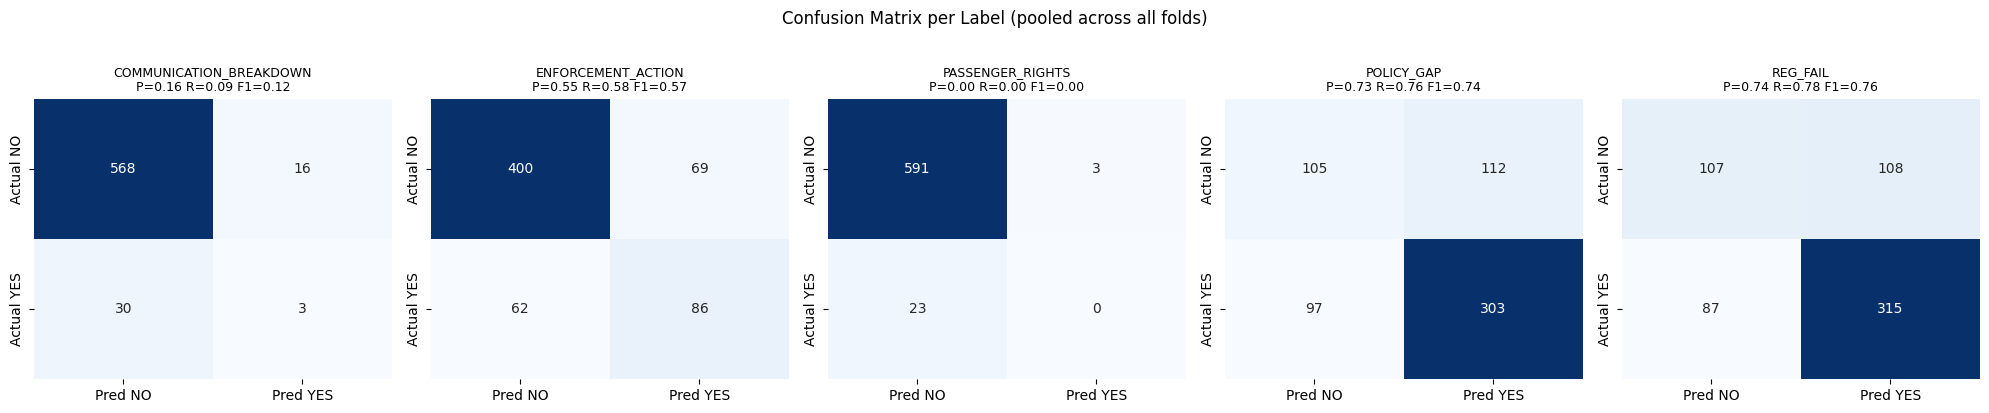

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import multilabel_confusion_matrix

# ── Confusion Matrix for each label ──────────────────────────
cms = multilabel_confusion_matrix(y_true_all, y_pred_all)

fig, axes = plt.subplots(1, len(CODES), figsize=(20, 4))

for i, (code, cm) in enumerate(zip(CODES, cms)):
    tn, fp, fn, tp = cm.ravel()

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=axes[i],
        xticklabels=['Pred NO', 'Pred YES'],
        yticklabels=['Actual NO', 'Actual YES'],
        cbar=False,
    )
    precision = tp/(tp+fp) if (tp+fp) > 0 else 0
    recall    = tp/(tp+fn) if (tp+fn) > 0 else 0
    f1        = 2*precision*recall/(precision+recall) if (precision+recall) > 0 else 0

    axes[i].set_title(f"{code}\nP={precision:.2f} R={recall:.2f} F1={f1:.2f}", fontsize=9)

plt.suptitle("Confusion Matrix per Label (pooled across all folds)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

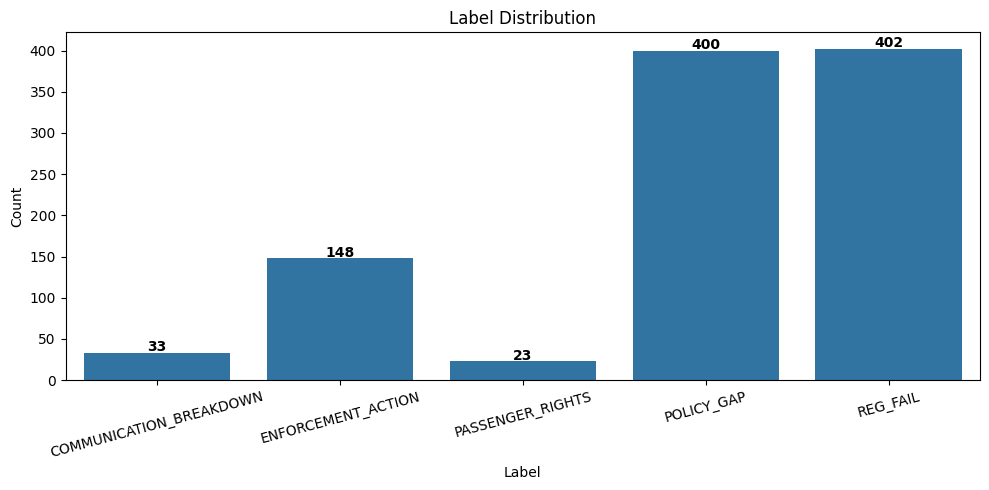

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

counts = [y[:, i].sum() for i in range(len(CODES))]
plt.figure(figsize=(10, 5))
sns.barplot(x=CODES, y=counts)
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=15)
for i, v in enumerate(counts):
    plt.text(i, v+2, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

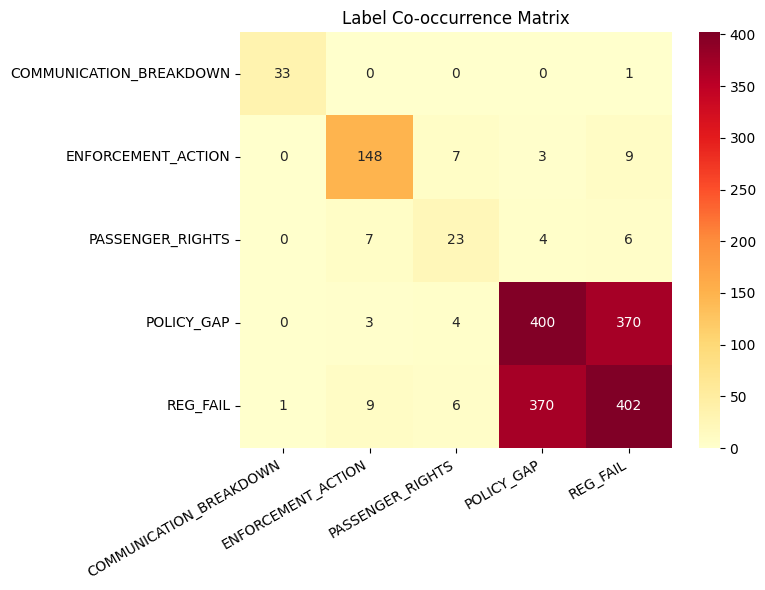

In [46]:
co_matrix = y.T @ y  # shape (5,5)
plt.figure(figsize=(8, 6))
sns.heatmap(
    co_matrix,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    xticklabels=CODES,
    yticklabels=CODES,
)
plt.title("Label Co-occurrence Matrix")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

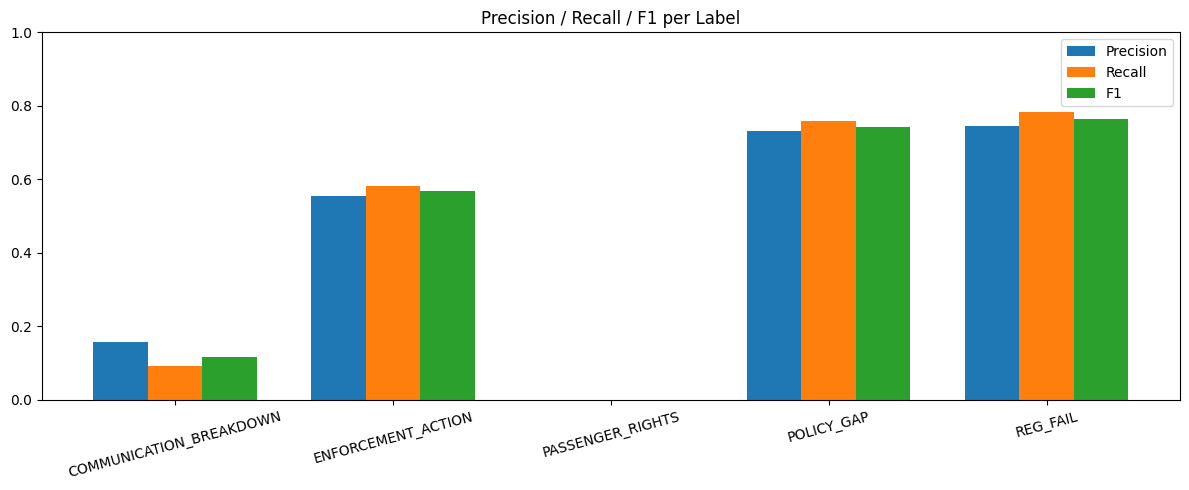

In [47]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_true_all, y_pred_all, average=None, zero_division=0)
recall    = recall_score(y_true_all, y_pred_all, average=None, zero_division=0)
f1        = f1_score(y_true_all, y_pred_all, average=None, zero_division=0)

x = np.arange(len(CODES))
width = 0.25

plt.figure(figsize=(12, 5))
plt.bar(x - width, precision, width, label='Precision')
plt.bar(x,         recall,    width, label='Recall')
plt.bar(x + width, f1,        width, label='F1')
plt.xticks(x, CODES, rotation=15)
plt.ylim(0, 1)
plt.title("Precision / Recall / F1 per Label")
plt.legend()
plt.tight_layout()
plt.show()

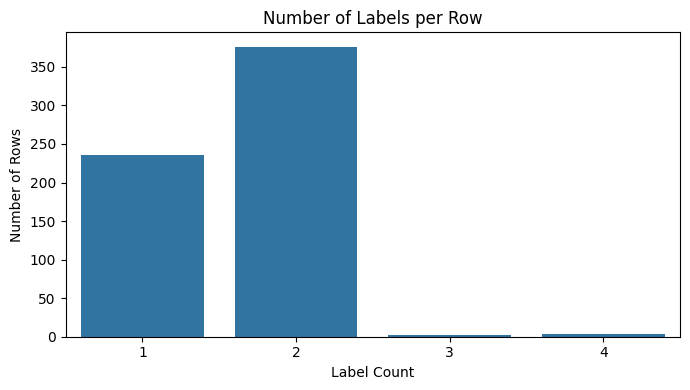

In [48]:
labels_per_row = y.sum(axis=1)
plt.figure(figsize=(7, 4))
sns.countplot(x=labels_per_row)
plt.title("Number of Labels per Row")
plt.xlabel("Label Count")
plt.ylabel("Number of Rows")
plt.tight_layout()
plt.show()

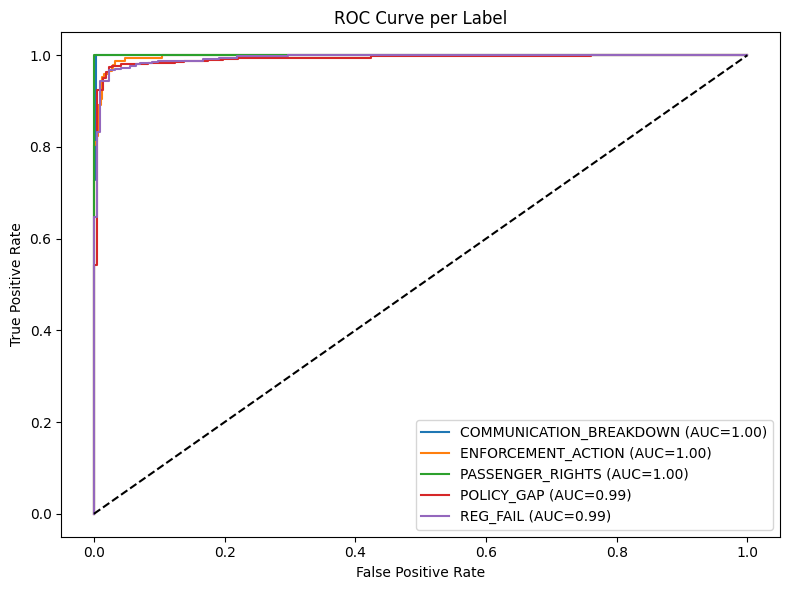

In [49]:
from sklearn.metrics import roc_curve, auc

# Need predict_proba — use final_clf
y_scores = final_clf.predict_proba(X_full)

plt.figure(figsize=(8, 6))
for i, code in enumerate(CODES):
    fpr, tpr, _ = roc_curve(y[:, i], y_scores[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{code} (AUC={roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve per Label")
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()